# BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding

**Learning notebook: paper review + method + mathematics + experiments + implementation + scikit-learn dataset project**

Paper: Jacob Devlin, Ming-Wei Chang, Kenton Lee, and Kristina Toutanova, *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*, arXiv:1810.04805 / NAACL 2019.

This notebook follows a research-paper study workflow:

1. Understand the problem, importance, idea, and contributions.
2. Break down the method: input, output, architecture, objectives, loss, and data flow.
3. Draw and explain the architecture.
4. Study the main mathematics.
5. Analyze experiments, baselines, metrics, results, and ablations.
6. Implement key BERT-style components in code.
7. Complete a project using a scikit-learn dataset: `fetch_20newsgroups` text classification.

Language style note: explanations use **we/our** rather than direct second-person wording.

## Notebook roadmap

| Section | Purpose |
|---|---|
| Paper review | Understand the research question and contribution |
| Method | Inspect BERT input, output, architecture, objective, and data flow |
| Architecture | Visualize how text becomes contextual representations |
| Mathematics | Decode formulas used in attention, MLM, NSP, classification, and QA |
| Experiments | Study datasets, baselines, metrics, tables, and ablations |
| Coding lab | Implement BERT-style masking, embedding composition, and tiny BERT heads |
| Project | Build a text classifier with scikit-learn data and compare baselines with BERT-style features |

# Part A — Paper Review

## What problem are the authors solving?

Before BERT, many strong language representation methods were limited in one of two ways:

1. **Feature-based approaches** such as ELMo used pre-trained representations as extra features, but downstream systems still required task-specific architectures.
2. **Fine-tuning approaches** such as OpenAI GPT were easier to adapt, but GPT used left-to-right language modeling, meaning each token could only attend to earlier tokens during pre-training.

The core problem: **how can a single pre-trained model learn deep bidirectional language representations and be fine-tuned for many NLP tasks with minimal task-specific architecture changes?**

This matters because many NLP tasks need both left and right context. For example:

- In question answering, the answer span may depend on words before and after the answer.
- In natural language inference, the relationship between two sentences depends on both directions of interaction.
- In named entity recognition, a token label often depends on the full sentence context.

## Why is the problem important?

The problem is important for four reasons:

1. **General language understanding**: A useful model should support classification, question answering, sentence-pair reasoning, and token labeling.
2. **Less manual architecture engineering**: Older systems often needed custom layers for each task. BERT aims to reuse one base encoder and only add a small task head.
3. **Better use of unlabeled text**: Labeled NLP datasets are costly, but unlabeled text is abundant. BERT uses self-supervised pre-training on large corpora.
4. **Bidirectional context**: Human language understanding usually depends on context from both sides, not only previous words.

## Main idea

BERT stands for **Bidirectional Encoder Representations from Transformers**.

The main idea is:

> Pre-train a deep Transformer encoder using self-supervised objectives that allow every token to condition on both left and right context, then fine-tune the same model for many downstream NLP tasks.

BERT uses two pre-training tasks:

1. **Masked Language Modeling (MLM)**: Randomly select 15% of tokens and train the model to predict the original tokens from context.
2. **Next Sentence Prediction (NSP)**: Train the model to decide whether sentence B really follows sentence A in the original document.

The key architecture choice is **bidirectional self-attention**. Every token can attend to every other token in the input sequence.

## Contributions

The paper makes three main contributions:

1. **Deep bidirectional pre-training**: BERT uses MLM to train representations that jointly condition on left and right context in every layer.
2. **Unified fine-tuning framework**: The same pre-trained encoder can be fine-tuned for sentence-level and token-level tasks by adding only a small output layer.
3. **State-of-the-art results on 11 NLP tasks**: BERT substantially improved results on GLUE, MultiNLI, SQuAD v1.1, SQuAD v2.0, and SWAG at the time of publication.

# Part B — Understand the Method

## Method summary

| Component | BERT design |
|---|---|
| Input | One sequence or a pair of sequences packed as `[CLS] sentence A [SEP] sentence B [SEP]` |
| Tokenization | WordPiece vocabulary with about 30,000 tokens |
| Embeddings | Token embedding + segment embedding + position embedding |
| Encoder | Multi-layer bidirectional Transformer encoder |
| Pre-training output | MLM predictions for selected masked positions + NSP prediction from `[CLS]` |
| Fine-tuning output | Task-specific layer on top of `[CLS]` for classification or token vectors for token-level tasks |
| Objective | Sum of MLM loss and NSP loss during pre-training; task loss during fine-tuning |
| Loss function | Cross-entropy for MLM, NSP, classification; span start/end cross-entropy for QA |

## Input representation

BERT represents a single sentence or sentence pair as one token sequence.

Example sentence-pair input:

```text
[CLS] the movie was surprisingly good [SEP] the acting was strong [SEP]
```

Each token representation is built from three embeddings:

\[
x_i = E_{token}(t_i) + E_{segment}(s_i) + E_{position}(i)
\]

Meaning:

- \(t_i\): token id at position \(i\)
- \(s_i\): segment id, usually 0 for sentence A and 1 for sentence B
- \(i\): token position
- \(x_i\): final input vector passed to the Transformer encoder

Why this is needed:

- Token embeddings identify words/subwords.
- Segment embeddings identify which sentence each token belongs to.
- Position embeddings preserve word order because self-attention alone is order-insensitive.

## Output representation

BERT produces one contextual vector for every input token:

```text
Input tokens:  [CLS]    token_1    token_2    ...    [SEP]
Output vecs:      C        T_1        T_2    ...      T_n
```

Output usage:

- \(C\), the final hidden state of `[CLS]`, is used for sequence-level classification.
- \(T_i\), the final hidden state of token \(i\), is used for token-level tasks such as NER, MLM, and extractive question answering.

## Model architecture

BERT is a stack of Transformer encoder blocks.

Two official sizes from the paper:

| Model | Layers \(L\) | Hidden size \(H\) | Attention heads \(A\) | Parameters |
|---|---:|---:|---:|---:|
| BERT_BASE | 12 | 768 | 12 | 110M |
| BERT_LARGE | 24 | 1024 | 16 | 340M |

BERT_BASE was designed to be comparable in size to OpenAI GPT, but with a crucial difference: **BERT uses bidirectional self-attention**, while GPT used left-to-right self-attention.

## BERT architecture diagram

```mermaid
flowchart TD
    A[Raw text: sentence A or sentence pair A/B]
    B[WordPiece tokenization]
    C[[CLS] A tokens [SEP] B tokens [SEP]]
    D[Token embeddings]
    E[Segment embeddings]
    F[Position embeddings]
    G[Sum embeddings]
    H[Transformer Encoder Block 1]
    I[Transformer Encoder Block 2]
    J[...]
    K[Transformer Encoder Block L]
    L1[Contextual token vectors T1...Tn]
    L2[[CLS] vector C]
    M1[MLM head for masked token prediction]
    M2[NSP head for IsNext / NotNext]
    M3[Fine-tuning task head]

    A --> B --> C
    C --> D --> G
    C --> E --> G
    C --> F --> G
    G --> H --> I --> J --> K
    K --> L1 --> M1
    K --> L2 --> M2
    L1 --> M3
    L2 --> M3
```

If Mermaid is not rendered in the notebook environment, the same idea is:

```text
Raw text
  ↓
WordPiece tokens + [CLS]/[SEP]
  ↓
Token + Segment + Position embeddings
  ↓
Bidirectional Transformer Encoder × L
  ↓
Contextual token vectors + [CLS] vector
  ↓
MLM / NSP during pre-training, task head during fine-tuning
```

## Data flow

### Pre-training data flow

1. Sample sentence A and sentence B from a document-level corpus.
2. 50% of the time, sentence B is the true next sentence; 50% of the time, it is randomly sampled.
3. Tokenize with WordPiece.
4. Pack as `[CLS] A [SEP] B [SEP]`.
5. Randomly select 15% of tokens for MLM prediction.
6. Replace selected tokens using the 80/10/10 rule:
   - 80% become `[MASK]`
   - 10% become a random token
   - 10% remain unchanged
7. Pass the sequence through the bidirectional Transformer encoder.
8. Predict masked tokens using token-level vectors.
9. Predict IsNext/NotNext using the `[CLS]` vector.
10. Minimize MLM loss + NSP loss.

### Fine-tuning data flow

1. Convert a downstream task example into the BERT input format.
2. Initialize BERT from pre-trained weights.
3. Add a small task-specific output layer.
4. Fine-tune all parameters end-to-end using labeled data.

# Part C — Study the Mathematics

## Embedding composition equation

\[
x_i = E_{token}(t_i) + E_{segment}(s_i) + E_{position}(i)
\]

| Question | Answer |
|---|---|
| What is this equation computing? | It computes the final input vector for token position \(i\). |
| Why do we need it? | BERT must know token identity, sentence membership, and position. |
| Where is it used? | Before the first Transformer encoder block. |
| Variables | \(t_i\) token id, \(s_i\) segment id, \(i\) position index, \(x_i\) final input vector. |

## Scaled dot-product attention

\[
\text{Attention}(Q,K,V)=\text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
\]

| Question | Answer |
|---|---|
| What is this equation computing? | A weighted mixture of value vectors based on query-key similarity. |
| Why do we need it? | Each token can gather useful information from all other tokens. |
| Where is it used? | Inside every self-attention head of every Transformer encoder block. |
| Variables | \(Q\): queries, \(K\): keys, \(V\): values, \(d_k\): key dimension. |

Interpretation:

- \(QK^T\) measures how strongly tokens should attend to one another.
- Division by \(\sqrt{d_k}\) stabilizes scale.
- `softmax` converts scores into attention weights.
- Multiplication by \(V\) produces contextual representations.

## Multi-head attention

\[
\text{MultiHead}(Q,K,V)=\text{Concat}(head_1,\ldots,head_h)W^O
\]

\[
head_j=\text{Attention}(QW_j^Q,KW_j^K,VW_j^V)
\]

| Question | Answer |
|---|---|
| What is this computing? | Several attention operations in parallel, followed by concatenation and projection. |
| Why do we need it? | Different heads can capture different relationships: syntax, coreference, topic, sentence-pair interaction. |
| Where is it used? | Inside every Transformer encoder layer. |
| Variables | \(h\): number of heads, \(W_j^Q,W_j^K,W_j^V,W^O\): learned projection matrices. |

## Masked Language Modeling probability

For a selected masked token position \(m\):

\[
p(t_m \mid X_{masked}) = \text{softmax}(W h_m + b)
\]

| Question | Answer |
|---|---|
| What is this computing? | A probability distribution over the vocabulary for the original token at masked position \(m\). |
| Why do we need it? | MLM forces BERT to learn bidirectional contextual representations. |
| Where is it used? | In the MLM pre-training head. |
| Variables | \(h_m\): final hidden state at masked position, \(W,b\): output layer parameters, \(t_m\): true token id. |

## MLM loss

\[
\mathcal{L}_{MLM} = -\sum_{m \in M}\log p(t_m \mid X_{masked})
\]

| Question | Answer |
|---|---|
| What is this computing? | Cross-entropy loss over selected masked positions. |
| Why do we need it? | It trains the model to recover missing words from left and right context. |
| Where is it used? | During BERT pre-training. |
| Variables | \(M\): set of selected positions, \(t_m\): original token at position \(m\), \(X_{masked}\): corrupted input sequence. |

## Next Sentence Prediction loss

NSP uses the `[CLS]` vector \(C\):

\[
p(y \mid C)=\text{softmax}(W_{NSP}C+b_{NSP})
\]

\[
\mathcal{L}_{NSP}=-\log p(y \mid C)
\]

| Question | Answer |
|---|---|
| What is this computing? | A binary classification loss for IsNext vs NotNext. |
| Why do we need it? | It encourages sentence-pair relationship modeling. |
| Where is it used? | During BERT pre-training, especially for tasks like NLI and QA. |
| Variables | \(C\): `[CLS]` vector, \(y\): NSP label, \(W_{NSP},b_{NSP}\): classifier parameters. |

## Total pre-training loss

\[
\mathcal{L}_{BERT}=\mathcal{L}_{MLM}+\mathcal{L}_{NSP}
\]

This loss combines token-level learning and sentence-pair learning.

- MLM teaches word/subword understanding from context.
- NSP teaches relationship understanding between text segments.

## Fine-tuning classification loss

For classification, BERT uses the `[CLS]` vector:

\[
p(y \mid X)=\text{softmax}(WC+b)
\]

\[
\mathcal{L}_{cls}=-\log p(y_{true}\mid X)
\]

| Question | Answer |
|---|---|
| What is this computing? | Class probabilities and cross-entropy loss. |
| Why do we need it? | Many downstream tasks are sequence-level classification tasks. |
| Where is it used? | Sentiment classification, entailment, paraphrase detection, topic classification. |
| Variables | \(C\): `[CLS]` vector, \(W,b\): classification head, \(y\): class label. |

## Question answering start/end equations

For extractive QA, BERT predicts start and end positions.

Start probability:

\[
p_i^{start}=\frac{e^{S \cdot T_i}}{\sum_j e^{S \cdot T_j}}
\]

End probability:

\[
p_i^{end}=\frac{e^{E \cdot T_i}}{\sum_j e^{E \cdot T_j}}
\]

Candidate span score:

\[
score(i,j)=S \cdot T_i + E \cdot T_j
\]

| Question | Answer |
|---|---|
| What is this computing? | Probability of each token being answer start/end, then score for each span. |
| Why do we need it? | SQuAD requires an answer span from the passage. |
| Where is it used? | Fine-tuning and prediction for extractive QA. |
| Variables | \(T_i\): token vector, \(S\): learned start vector, \(E\): learned end vector, \(i,j\): start/end positions. |

# Part D — Analyze the Experiments

## Datasets used

### Pre-training datasets

| Dataset | Purpose |
|---|---|
| BooksCorpus | Long contiguous text for language and sentence relationship learning |
| English Wikipedia | Large document-level corpus for language understanding |

### Downstream evaluation datasets

| Benchmark | Tasks |
|---|---|
| GLUE | MNLI, QQP, QNLI, SST-2, CoLA, STS-B, MRPC, RTE, WNLI |
| SQuAD v1.1 | Extractive question answering with answer spans |
| SQuAD v2.0 | Extractive QA with unanswerable questions |
| SWAG | Commonsense sentence continuation among four choices |

## Baselines

The paper compares BERT against several strong systems:

| Baseline | Role |
|---|---|
| Pre-OpenAI SOTA | Best previous non-BERT systems on GLUE |
| BiLSTM + ELMo + Attention | Strong feature-based contextual embedding baseline |
| OpenAI GPT | Fine-tuning baseline with left-to-right Transformer language modeling |
| BiDAF + ELMo | Question answering baseline on SQuAD |
| R.M. Reader | Strong SQuAD reader baseline |
| ESIM + GloVe / ELMo | SWAG baselines |
| Human performance | Reference point on SQuAD and SWAG |

## Evaluation metrics

| Task type | Metrics |
|---|---|
| Classification | Accuracy |
| QQP / MRPC | F1 score |
| STS-B | Spearman correlation |
| CoLA | Matthews correlation coefficient |
| SQuAD | Exact Match and F1 |
| SWAG | Accuracy |

## Key GLUE results from the paper

| System | MNLI-m/mm | QQP | QNLI | SST-2 | CoLA | STS-B | MRPC | RTE | Average |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| Pre-OpenAI SOTA | 80.6/80.1 | 66.1 | 82.3 | 93.2 | 35.0 | 81.0 | 86.0 | 61.7 | 74.0 |
| BiLSTM+ELMo+Attn | 76.4/76.1 | 64.8 | 79.8 | 90.4 | 36.0 | 73.3 | 84.9 | 56.8 | 71.0 |
| OpenAI GPT | 82.1/81.4 | 70.3 | 87.4 | 91.3 | 45.4 | 80.0 | 82.3 | 56.0 | 75.1 |
| BERT_BASE | 84.6/83.4 | 71.2 | 90.5 | 93.5 | 52.1 | 85.8 | 88.9 | 66.4 | 79.6 |
| BERT_LARGE | 86.7/85.9 | 72.1 | 92.7 | 94.9 | 60.5 | 86.5 | 89.3 | 70.1 | 82.1 |

Main reading: BERT_LARGE strongly improved the average score, especially on tasks requiring sentence-pair reasoning and linguistic acceptability.

## SQuAD and SWAG results

### SQuAD v1.1

| System | Dev EM | Dev F1 | Test EM | Test F1 |
|---|---:|---:|---:|---:|
| Human | — | — | 82.3 | 91.2 |
| BiDAF+ELMo single | — | 85.6 | — | 85.8 |
| R.M. Reader ensemble | 81.2 | 87.9 | 82.3 | 88.5 |
| BERT_BASE single | 80.8 | 88.5 | — | — |
| BERT_LARGE single | 84.1 | 90.9 | — | — |
| BERT_LARGE ensemble + TriviaQA | 86.2 | 92.2 | 87.4 | 93.2 |

### SQuAD v2.0

| System | Dev EM | Dev F1 | Test EM | Test F1 |
|---|---:|---:|---:|---:|
| Human | 86.3 | 89.0 | 86.9 | 89.5 |
| Published unet ensemble | — | — | 71.4 | 74.9 |
| BERT_LARGE single | 78.7 | 81.9 | 80.0 | 83.1 |

### SWAG

| System | Dev accuracy | Test accuracy |
|---|---:|---:|
| ESIM + GloVe | 51.9 | 52.7 |
| ESIM + ELMo | 59.1 | 59.2 |
| OpenAI GPT | — | 78.0 |
| BERT_BASE | 81.6 | — |
| BERT_LARGE | 86.6 | 86.3 |
| Human expert | — | 85.0 |

## Ablation studies

### Effect of pre-training tasks

| Model | MNLI-m Acc | QNLI Acc | MRPC Acc | SST-2 Acc | SQuAD F1 |
|---|---:|---:|---:|---:|---:|
| BERT_BASE | 84.4 | 88.4 | 86.7 | 92.7 | 88.5 |
| No NSP | 83.9 | 84.9 | 86.5 | 92.6 | 87.9 |
| LTR & No NSP | 82.1 | 84.3 | 77.5 | 92.1 | 77.8 |
| LTR & No NSP + BiLSTM | 82.1 | 84.1 | 75.7 | 91.6 | 84.9 |

Reading:

- Removing NSP hurts QNLI and SQuAD noticeably.
- Replacing MLM with left-to-right LM causes large drops, especially on MRPC and SQuAD.
- Adding BiLSTM after a left-to-right model helps SQuAD but still remains weaker than deep bidirectional pre-training.

### Effect of model size

| Layers | Hidden | Heads | MLM perplexity | MNLI-m | MRPC | SST-2 |
|---:|---:|---:|---:|---:|---:|---:|
| 3 | 768 | 12 | 5.84 | 77.9 | 79.8 | 88.4 |
| 6 | 768 | 3 | 5.24 | 80.6 | 82.2 | 90.7 |
| 6 | 768 | 12 | 4.68 | 81.9 | 84.8 | 91.3 |
| 12 | 768 | 12 | 3.99 | 84.4 | 86.7 | 92.9 |
| 12 | 1024 | 16 | 3.54 | 85.7 | 86.9 | 93.3 |
| 24 | 1024 | 16 | 3.23 | 86.6 | 87.8 | 93.7 |

Reading: larger pre-trained encoders improve downstream accuracy even on relatively small datasets, provided pre-training is sufficiently large.

# Part E — Assumptions, Limitations, Failure Cases, Improvements, Applications

## Assumptions

BERT makes several assumptions:

1. **Large unlabeled corpora contain transferable linguistic knowledge.**
2. **Masked token prediction encourages useful bidirectional representations.**
3. **A single `[CLS]` vector can summarize a sequence for classification tasks.**
4. **Sentence A/B segment embeddings are enough for many sentence-pair tasks.**
5. **Fine-tuning all parameters is practical and beneficial for downstream datasets.**
6. **WordPiece tokenization can handle rare words through subwords.**

## Limitations

Important limitations:

1. **Pre-training is expensive**: Original pre-training required large TPU resources.
2. **Maximum input length is limited**: BERT commonly uses 512 tokens, which makes long documents difficult.
3. **MLM pre-training has a mismatch**: `[MASK]` appears during pre-training but not normal fine-tuning/inference.
4. **NSP later became debated**: Later models such as RoBERTa removed NSP and improved training recipes.
5. **No natural generation ability**: BERT is encoder-only, so it is not designed for left-to-right text generation.
6. **Static pre-training snapshot**: Knowledge is frozen after training unless fine-tuned or updated.
7. **Bias and fairness risks**: Pre-training text can encode social biases and harmful stereotypes.
8. **Domain mismatch**: General BERT may underperform in specialized domains without domain adaptation.

## Where might BERT fail?

BERT may fail when:

- Text is much longer than 512 tokens and important evidence is far apart.
- Domain-specific vocabulary is very different from BooksCorpus/Wikipedia.
- The task requires arithmetic, multi-hop reasoning, or external knowledge.
- The dataset is very small and fine-tuning overfits.
- Input contains noisy spelling, code-mixed language, OCR errors, or informal social media text.
- The output requires fluent generation rather than understanding/classification.

## How could BERT be improved?

Possible improvements:

1. **Better pre-training recipe**: Dynamic masking, larger batches, more data, longer training, and no NSP as explored by RoBERTa.
2. **Parameter efficiency**: ALBERT-style parameter sharing or distillation for smaller models.
3. **Long-context modeling**: Longformer, BigBird, or sparse attention for longer documents.
4. **Domain-adaptive pre-training**: BioBERT, SciBERT, LegalBERT, FinBERT, BanglaBERT-like adaptation.
5. **Multilingual/cross-lingual training**: Extend to many languages and low-resource settings.
6. **Retrieval augmentation**: Combine BERT representations with document retrieval for open-domain QA.
7. **Fairness and safety evaluation**: Measure and mitigate biases learned during pre-training.

## Could this idea be applied elsewhere?

Yes. The BERT idea is broadly useful wherever masked reconstruction plus bidirectional context helps representation learning.

Applications:

- **Text classification**: sentiment, topic, spam, intent detection.
- **Question answering**: span extraction and answer ranking.
- **Named entity recognition**: token classification.
- **Search and retrieval**: semantic ranking and passage matching.
- **Code understanding**: masked code token prediction.
- **Protein sequences**: masked amino acid prediction.
- **Images**: masked patch prediction, as in BERT-inspired vision models.
- **Tabular/text mixed data**: contextual representation of records and descriptions.

# Part F — Coding Lab Setup

The following sections include runnable code. The notebook is designed to be practical on modest hardware by using small subsets and optional lightweight models.

In [38]:
# Optional installation cell.
# Run this cell only when required packages are missing.
# In many hosted notebooks, scikit-learn, pandas, matplotlib, and torch are already available.

# %pip install -q scikit-learn pandas numpy matplotlib torch transformers accelerate datasets evaluate

In [39]:
import os
import random
import math
import textwrap
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## Visual architecture drawing with Matplotlib

This cell draws a simple BERT pipeline diagram. It does not train a model; it helps visualize data flow.

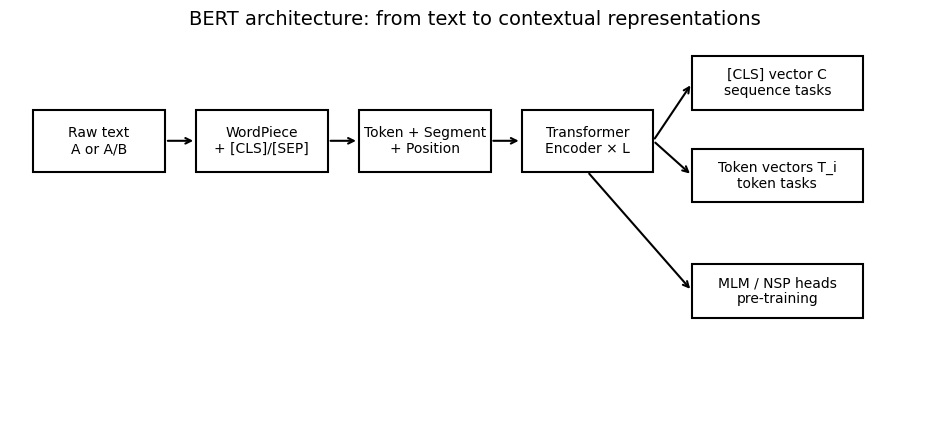

In [40]:
def draw_box(ax, xy, width, height, text, fontsize=10):
    x, y = xy
    rect = plt.Rectangle((x, y), width, height, fill=False, linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + width / 2, y + height / 2, text, ha='center', va='center', fontsize=fontsize, wrap=True)


def draw_arrow(ax, start, end):
    ax.annotate('', xy=end, xytext=start, arrowprops=dict(arrowstyle='->', linewidth=1.5))


fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, 12)
ax.set_ylim(0, 5)
ax.axis('off')

boxes = [
    ((0.3, 3.2), 1.7, 0.8, 'Raw text\nA or A/B'),
    ((2.4, 3.2), 1.7, 0.8, 'WordPiece\n+ [CLS]/[SEP]'),
    ((4.5, 3.2), 1.7, 0.8, 'Token + Segment\n+ Position'),
    ((6.6, 3.2), 1.7, 0.8, 'Transformer\nEncoder × L'),
    ((8.8, 4.0), 2.2, 0.7, '[CLS] vector C\nsequence tasks'),
    ((8.8, 2.8), 2.2, 0.7, 'Token vectors T_i\ntoken tasks'),
    ((8.8, 1.3), 2.2, 0.7, 'MLM / NSP heads\npre-training'),
]

for b in boxes:
    draw_box(ax, *b)

arrows = [
    ((2.0, 3.6), (2.4, 3.6)),
    ((4.1, 3.6), (4.5, 3.6)),
    ((6.2, 3.6), (6.6, 3.6)),
    ((8.3, 3.6), (8.8, 4.35)),
    ((8.3, 3.6), (8.8, 3.15)),
    ((7.45, 3.2), (8.8, 1.65)),
]
for a in arrows:
    draw_arrow(ax, *a)

ax.set_title('BERT architecture: from text to contextual representations', fontsize=14)
plt.show()

# Part G — Implement Key BERT Ideas from Scratch

This section implements simplified versions of the ideas, not the full 110M-parameter original model.

## Toy tokenizer and BERT-style input packing

The original BERT uses WordPiece. For a small educational implementation, a simple whitespace tokenizer is enough to show the data flow.

In [41]:
SPECIAL_TOKENS = ['[PAD]', '[UNK]', '[CLS]', '[SEP]', '[MASK]']


def simple_tokenize(text):
    text = text.lower().replace('.', ' .').replace(',', ' ,').replace('?', ' ?').replace('!', ' !')
    return text.split()


def build_vocab(texts, min_freq=1, max_size=5000):
    counter = Counter()
    for text in texts:
        counter.update(simple_tokenize(text))
    vocab = {tok: idx for idx, tok in enumerate(SPECIAL_TOKENS)}
    for token, freq in counter.most_common(max_size - len(SPECIAL_TOKENS)):
        if freq >= min_freq and token not in vocab:
            vocab[token] = len(vocab)
    return vocab


def encode_sentence_pair(sentence_a, sentence_b, vocab, max_len=64):
    tokens_a = simple_tokenize(sentence_a)
    tokens_b = simple_tokenize(sentence_b)
    tokens = ['[CLS]'] + tokens_a + ['[SEP]'] + tokens_b + ['[SEP]']
    segment_ids = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
    tokens = tokens[:max_len]
    segment_ids = segment_ids[:max_len]
    input_ids = [vocab.get(tok, vocab['[UNK]']) for tok in tokens]
    attention_mask = [1] * len(input_ids)
    pad_len = max_len - len(input_ids)
    input_ids += [vocab['[PAD]']] * pad_len
    segment_ids += [0] * pad_len
    attention_mask += [0] * pad_len
    return {
        'tokens': tokens,
        'input_ids': input_ids,
        'segment_ids': segment_ids,
        'attention_mask': attention_mask,
    }


sample_texts = [
    'The model reads left and right context.',
    'Masked language modeling predicts hidden tokens.',
    'Sentence pairs are useful for question answering.'
]
vocab = build_vocab(sample_texts)
example = encode_sentence_pair(sample_texts[0], sample_texts[1], vocab, max_len=24)
example

{'tokens': ['[CLS]',
  'the',
  'model',
  'reads',
  'left',
  'and',
  'right',
  'context',
  '.',
  '[SEP]',
  'masked',
  'language',
  'modeling',
  'predicts',
  'hidden',
  'tokens',
  '.',
  '[SEP]'],
 'input_ids': [2,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  5,
  3,
  13,
  14,
  15,
  16,
  17,
  18,
  5,
  3,
  0,
  0,
  0,
  0,
  0,
  0],
 'segment_ids': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0],
 'attention_mask': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0]}

## MLM masking function: 15% selection and 80/10/10 replacement

In [42]:
def apply_mlm_masking(input_ids, vocab, mask_prob=0.15):
    input_ids = list(input_ids)
    labels = [-100] * len(input_ids)  # -100 means ignored by PyTorch CrossEntropyLoss
    token_ids = list(vocab.values())
    special_ids = {vocab[tok] for tok in SPECIAL_TOKENS}

    for idx, token_id in enumerate(input_ids):
        if token_id in special_ids:
            continue
        if random.random() < mask_prob:
            labels[idx] = token_id
            r = random.random()
            if r < 0.80:
                input_ids[idx] = vocab['[MASK]']
            elif r < 0.90:
                input_ids[idx] = random.choice(token_ids)
            else:
                input_ids[idx] = token_id
    return input_ids, labels


masked_ids, mlm_labels = apply_mlm_masking(example['input_ids'], vocab)
id_to_token = {idx: tok for tok, idx in vocab.items()}

pd.DataFrame({
    'position': list(range(len(masked_ids))),
    'masked_input': [id_to_token.get(i, '[UNK]') for i in masked_ids],
    'mlm_label': [id_to_token.get(i, 'IGNORE') if i != -100 else 'IGNORE' for i in mlm_labels]
}).head(24)

,position,masked_input,mlm_label
0,0,[CLS],IGNORE
1,1,the,IGNORE
2,2,[MASK],model
3,3,reads,IGNORE
4,4,left,IGNORE
5,5,and,IGNORE
6,6,right,IGNORE
7,7,[MASK],context
8,8,[MASK],.
9,9,[SEP],IGNORE


## Tiny BERT-style model in PyTorch

This is a compact educational model:

- token + segment + position embeddings
- Transformer encoder stack
- MLM head for masked token prediction
- NSP head from `[CLS]`

It shows how the original solution can be implemented conceptually.

In [43]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TinyBertEmbeddings(nn.Module):
    def __init__(self, vocab_size, hidden_size=128, max_len=128, type_vocab_size=2, dropout=0.1):
        super().__init__()
        self.token_embeddings = nn.Embedding(vocab_size, hidden_size)
        self.position_embeddings = nn.Embedding(max_len, hidden_size)
        self.segment_embeddings = nn.Embedding(type_vocab_size, hidden_size)
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids, token_type_ids):
        batch_size, seq_len = input_ids.shape
        positions = torch.arange(seq_len, device=input_ids.device).unsqueeze(0).expand(batch_size, seq_len)
        x = (
            self.token_embeddings(input_ids)
            + self.position_embeddings(positions)
            + self.segment_embeddings(token_type_ids)
        )
        return self.dropout(self.layer_norm(x))


class TinyBertForPreTraining(nn.Module):
    def __init__(self, vocab_size, hidden_size=128, num_layers=2, num_heads=4, max_len=128):
        super().__init__()
        self.embeddings = TinyBertEmbeddings(vocab_size, hidden_size, max_len=max_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_size,
            nhead=num_heads,
            dim_feedforward=hidden_size * 4,
            dropout=0.1,
            activation='gelu',
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.mlm_head = nn.Linear(hidden_size, vocab_size)
        self.nsp_head = nn.Linear(hidden_size, 2)

    def forward(self, input_ids, token_type_ids, attention_mask=None):
        x = self.embeddings(input_ids, token_type_ids)
        src_key_padding_mask = None
        if attention_mask is not None:
            src_key_padding_mask = attention_mask == 0
        h = self.encoder(x, src_key_padding_mask=src_key_padding_mask)
        mlm_logits = self.mlm_head(h)
        cls_vector = h[:, 0, :]
        nsp_logits = self.nsp_head(cls_vector)
        return mlm_logits, nsp_logits


# Shape test
vocab_size = len(vocab)
model = TinyBertForPreTraining(vocab_size=vocab_size, hidden_size=64, num_layers=1, num_heads=4, max_len=24)
input_tensor = torch.tensor([masked_ids], dtype=torch.long)
segment_tensor = torch.tensor([example['segment_ids']], dtype=torch.long)
mask_tensor = torch.tensor([example['attention_mask']], dtype=torch.long)

mlm_logits, nsp_logits = model(input_tensor, segment_tensor, mask_tensor)
print('MLM logits shape:', mlm_logits.shape)
print('NSP logits shape:', nsp_logits.shape)

MLM logits shape: torch.Size([1, 24, 26])
NSP logits shape: torch.Size([1, 2])


## MLM + NSP loss demonstration

In [44]:
mlm_label_tensor = torch.tensor([mlm_labels], dtype=torch.long)
nsp_label_tensor = torch.tensor([1], dtype=torch.long)  # 1 can represent IsNext in this toy setup

mlm_loss = F.cross_entropy(
    mlm_logits.view(-1, vocab_size),
    mlm_label_tensor.view(-1),
    ignore_index=-100,
)
nsp_loss = F.cross_entropy(nsp_logits, nsp_label_tensor)
total_loss = mlm_loss + nsp_loss

print('MLM loss:', round(float(mlm_loss.detach()), 4))
print('NSP loss:', round(float(nsp_loss.detach()), 4))
print('Total pre-training loss:', round(float(total_loss.detach()), 4))

MLM loss: 3.2056
NSP loss: 1.017
Total pre-training loss: 4.2226


# Part H — Project with scikit-learn Dataset

Project goal: **classify news topics using a scikit-learn text dataset and compare classical ML with BERT-style representations.**

Dataset: `fetch_20newsgroups` from scikit-learn.

Pipeline:

1. Load a subset of 20 Newsgroups.
2. Train a strong TF-IDF + Logistic Regression baseline.
3. Extract BERT-family contextual embeddings with a pre-trained encoder.
4. Train Logistic Regression on those embeddings.
5. Optionally fine-tune a lightweight Transformer classifier.
6. Compare metrics and discuss results.

## Load scikit-learn dataset

The selected categories keep runtime manageable while still creating a real multi-class text classification task.

In [45]:
categories = [
    'comp.graphics',
    'rec.sport.baseball',
    'sci.med',
    'talk.politics.misc',
]

try:
    raw_train = fetch_20newsgroups(
        subset='train',
        categories=categories,
        remove=('headers', 'footers', 'quotes'),
        shuffle=True,
        random_state=SEED,
    )
    raw_test = fetch_20newsgroups(
        subset='test',
        categories=categories,
        remove=('headers', 'footers', 'quotes'),
        shuffle=True,
        random_state=SEED,
    )
    X_train_text = raw_train.data
    y_train = raw_train.target
    X_test_text = raw_test.data
    y_test = raw_test.target
    target_names = raw_train.target_names
except Exception as exc:
    raise RuntimeError(
        'The scikit-learn 20 Newsgroups dataset could not be fetched. '
        'A working internet connection may be required by scikit-learn on the first run.'
    ) from exc

print('Train size:', len(X_train_text))
print('Test size:', len(X_test_text))
print('Classes:', target_names)
print('\nSample document preview:\n')
print(textwrap.shorten(X_train_text[0].replace('\n', ' '), width=500))

Train size: 2240
Test size: 1492
Classes: ['comp.graphics', 'rec.sport.baseball', 'sci.med', 'talk.politics.misc']

Sample document preview:

The speculum is the little cone that fits on the end of the otoscope. There are also vaginal specula that females and gynecologists are all too familiar with. -- ---------------------------------------------------------------------------- Gordon Banks N3JXP | "Skepticism is the chastity of the intellect, and geb@cadre.dsl.pitt.edu | it is shameful to surrender it too soon."


## Exploratory data analysis

,count
class_name,
comp.graphics,584
rec.sport.baseball,597
sci.med,594
talk.politics.misc,465


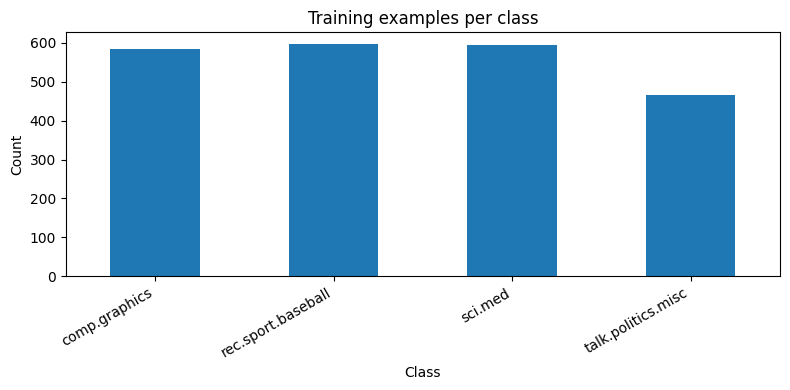

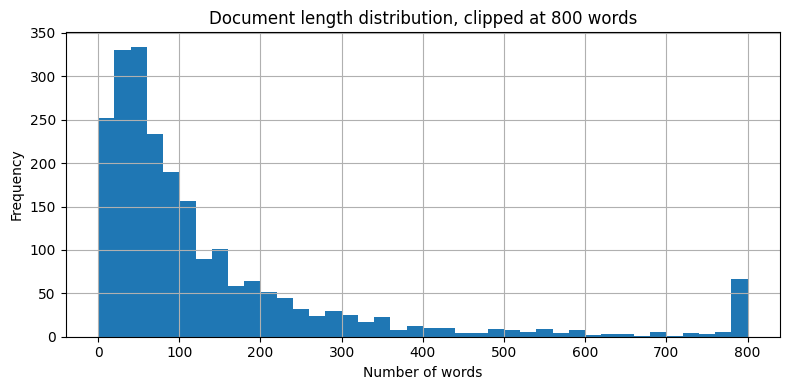

In [46]:
train_df = pd.DataFrame({'text': X_train_text, 'label': y_train})
train_df['class_name'] = train_df['label'].map(lambda x: target_names[x])
train_df['num_words'] = train_df['text'].str.split().map(len)

class_counts = train_df['class_name'].value_counts().sort_index()
display(class_counts.to_frame('count'))

fig, ax = plt.subplots(figsize=(8, 4))
class_counts.plot(kind='bar', ax=ax)
ax.set_title('Training examples per class')
ax.set_ylabel('Count')
ax.set_xlabel('Class')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
train_df['num_words'].clip(upper=800).hist(bins=40, ax=ax)
ax.set_title('Document length distribution, clipped at 800 words')
ax.set_xlabel('Number of words')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

## Baseline: TF-IDF + Logistic Regression

This baseline is strong for many text classification datasets. It gives a practical reference point before using BERT.

In [47]:
tfidf_lr = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=30000, ngram_range=(1, 2), min_df=2, stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000, n_jobs=None, C=4.0, random_state=SEED)),
])

tfidf_lr.fit(X_train_text, y_train)
y_pred_tfidf = tfidf_lr.predict(X_test_text)

acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
f1_tfidf = f1_score(y_test, y_pred_tfidf, average='macro')

print('TF-IDF + Logistic Regression')
print('Accuracy:', round(acc_tfidf, 4))
print('Macro F1:', round(f1_tfidf, 4))
print('\nClassification report:\n')
print(classification_report(y_test, y_pred_tfidf, target_names=target_names))

TF-IDF + Logistic Regression
Accuracy: 0.882
Macro F1: 0.8802

Classification report:

                    precision    recall  f1-score   support

     comp.graphics       0.91      0.91      0.91       389
rec.sport.baseball       0.85      0.93      0.89       397
           sci.med       0.88      0.85      0.87       396
talk.politics.misc       0.88      0.83      0.85       310

          accuracy                           0.88      1492
         macro avg       0.88      0.88      0.88      1492
      weighted avg       0.88      0.88      0.88      1492



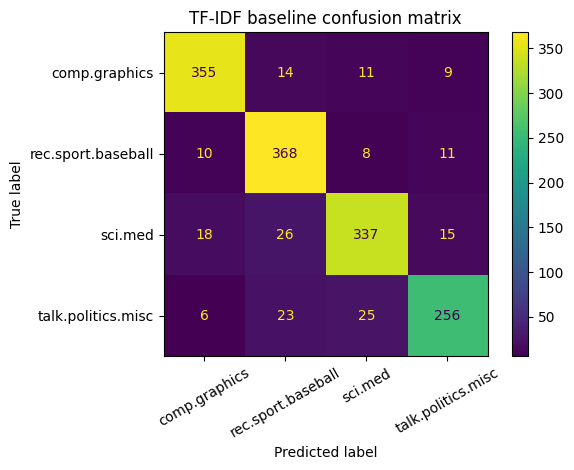

In [48]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tfidf,
    display_labels=target_names,
    xticks_rotation=30,
)
plt.title('TF-IDF baseline confusion matrix')
plt.tight_layout()
plt.show()

## BERT-family feature extraction

This section uses a pre-trained Transformer encoder to convert each document into a dense vector, then trains Logistic Regression on those vectors.

For fast runtime, the default model is `prajjwal1/bert-tiny`. This is not the original BERT_BASE; it is a small BERT-family model suitable for learning and experimentation. For stronger results, replace it with `bert-base-uncased` when compute allows.

In [49]:
# This cell requires transformers and torch.
# It may download a small pre-trained model on first run.

USE_BERT_FEATURES = True
MODEL_NAME = 'prajjwal1/bert-tiny'  # alternatives: 'bert-base-uncased', 'distilbert-base-uncased'
MAX_LENGTH = 192
BATCH_SIZE = 16
MAX_TRAIN_DOCS_FOR_BERT = 800
MAX_TEST_DOCS_FOR_BERT = 400

In [50]:
def select_balanced_subset(texts, labels, max_docs, seed=SEED):
    rng = np.random.default_rng(seed)
    labels = np.asarray(labels)
    selected = []
    per_class = max(1, max_docs // len(np.unique(labels)))
    for cls in np.unique(labels):
        idx = np.where(labels == cls)[0]
        take = min(per_class, len(idx))
        selected.extend(rng.choice(idx, size=take, replace=False).tolist())
    rng.shuffle(selected)
    return [texts[i] for i in selected], labels[selected]


X_train_bert_text, y_train_bert = select_balanced_subset(X_train_text, y_train, MAX_TRAIN_DOCS_FOR_BERT)
X_test_bert_text, y_test_bert = select_balanced_subset(X_test_text, y_test, MAX_TEST_DOCS_FOR_BERT)

print('BERT feature train subset:', len(X_train_bert_text))
print('BERT feature test subset:', len(X_test_bert_text))

BERT feature train subset: 800
BERT feature test subset: 400


In [51]:
if USE_BERT_FEATURES:
    try:
        from transformers import AutoTokenizer, AutoModel

        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
        encoder = AutoModel.from_pretrained(MODEL_NAME).to(device)
        encoder.eval()

        def mean_pool(last_hidden_state, attention_mask):
            mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
            summed = torch.sum(last_hidden_state * mask, dim=1)
            counts = torch.clamp(mask.sum(dim=1), min=1e-9)
            return summed / counts

        @torch.no_grad()
        def encode_texts(texts, batch_size=BATCH_SIZE, verbose=True, report_every=10):
            all_vectors = []
            n_batches = (len(texts) + batch_size - 1) // batch_size
            for i, start in enumerate(range(0, len(texts), batch_size)):
                if verbose and (i % report_every == 0 or i == n_batches - 1):
                    print(f'Encoding batch {i+1}/{n_batches} ({min(start+batch_size, len(texts))}/{len(texts)} docs)')
                batch_texts = texts[start:start + batch_size]
                batch = tokenizer(
                    batch_texts,
                    padding=True,
                    truncation=True,
                    max_length=MAX_LENGTH,
                    return_tensors='pt',
                ).to(device)
                outputs = encoder(**batch)
                vectors = mean_pool(outputs.last_hidden_state, batch['attention_mask'])
                all_vectors.append(vectors.cpu().numpy())
            return np.vstack(all_vectors)

        X_train_bert_vec = encode_texts(X_train_bert_text)
        X_test_bert_vec = encode_texts(X_test_bert_text)
        print('Embedding shape:', X_train_bert_vec.shape)
    except Exception as exc:
        USE_BERT_FEATURES = False
        print('BERT feature extraction skipped because an error occurred:')
        print(type(exc).__name__, str(exc)[:500])

BERT feature extraction skipped because an error occurred:
ValueError Couldn't instantiate the backend tokenizer from one of: 
(1) a `tokenizers` library serialization file, 
(2) a slow tokenizer instance to convert or 
(3) an equivalent slow tokenizer class to instantiate and convert. 
You need to have sentencepiece or tiktoken installed to convert a slow tokenizer to a fast one.


In [52]:
if USE_BERT_FEATURES:
    bert_lr = LogisticRegression(max_iter=1000, C=2.0, random_state=SEED)
    bert_lr.fit(X_train_bert_vec, y_train_bert)
    y_pred_bert = bert_lr.predict(X_test_bert_vec)

    acc_bert = accuracy_score(y_test_bert, y_pred_bert)
    f1_bert = f1_score(y_test_bert, y_pred_bert, average='macro')

    print('Frozen BERT-family embeddings + Logistic Regression')
    print('Accuracy:', round(acc_bert, 4))
    print('Macro F1:', round(f1_bert, 4))
    print('\nClassification report:\n')
    print(classification_report(y_test_bert, y_pred_bert, target_names=target_names))
else:
    acc_bert = np.nan
    f1_bert = np.nan
    print('No BERT-family result available in this run.')

No BERT-family result available in this run.


## Compare baseline and BERT-family feature results

,model,accuracy,macro_f1,train_docs,test_docs
0,TF-IDF + Logistic Regression,0.882038,0.880209,2240,1492
1,prajjwal1/bert-tiny embeddings + Logistic Regr...,NaN,NaN,800,400


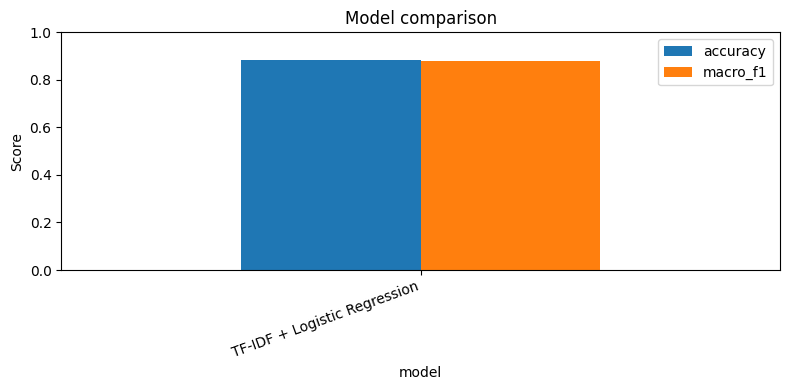

In [53]:
results = pd.DataFrame([
    {'model': 'TF-IDF + Logistic Regression', 'accuracy': acc_tfidf, 'macro_f1': f1_tfidf, 'train_docs': len(X_train_text), 'test_docs': len(X_test_text)},
    {'model': f'{MODEL_NAME} embeddings + Logistic Regression', 'accuracy': acc_bert, 'macro_f1': f1_bert, 'train_docs': len(X_train_bert_text), 'test_docs': len(X_test_bert_text)},
])

display(results)

fig, ax = plt.subplots(figsize=(8, 4))
plot_df = results.dropna(subset=['macro_f1']).set_index('model')[['accuracy', 'macro_f1']]
plot_df.plot(kind='bar', ax=ax)
ax.set_title('Model comparison')
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## Optional: fine-tune a lightweight BERT classifier

This optional section fine-tunes a lightweight Transformer classifier directly. It can take longer and may require a GPU.

Default: disabled. Set `RUN_FINE_TUNING = True` to run.

In [54]:
RUN_FINE_TUNING = False
FINE_TUNE_MODEL = 'prajjwal1/bert-tiny'
MAX_FINE_TUNE_TRAIN = 600
MAX_FINE_TUNE_TEST = 300

In [55]:
if RUN_FINE_TUNING:
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
    from datasets import Dataset

    X_ft_train, y_ft_train = select_balanced_subset(X_train_text, y_train, MAX_FINE_TUNE_TRAIN)
    X_ft_test, y_ft_test = select_balanced_subset(X_test_text, y_test, MAX_FINE_TUNE_TEST)

    ft_tokenizer = AutoTokenizer.from_pretrained(FINE_TUNE_MODEL)

    train_ds = Dataset.from_dict({'text': X_ft_train, 'label': list(map(int, y_ft_train))})
    test_ds = Dataset.from_dict({'text': X_ft_test, 'label': list(map(int, y_ft_test))})

    def tokenize_batch(batch):
        return ft_tokenizer(batch['text'], padding='max_length', truncation=True, max_length=MAX_LENGTH)

    train_ds = train_ds.map(tokenize_batch, batched=True)
    test_ds = test_ds.map(tokenize_batch, batched=True)
    train_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
    test_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

    ft_model = AutoModelForSequenceClassification.from_pretrained(
        FINE_TUNE_MODEL,
        num_labels=len(target_names),
    )

    args = TrainingArguments(
        output_dir='./bert_tiny_20news_outputs',
        eval_strategy='epoch',
        save_strategy='no',
        learning_rate=3e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=3,
        weight_decay=0.01,
        logging_steps=20,
        report_to=[],
        seed=SEED,
    )

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        return {
            'accuracy': accuracy_score(labels, preds),
            'macro_f1': f1_score(labels, preds, average='macro'),
        }

    trainer = Trainer(
        model=ft_model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=test_ds,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    fine_tune_metrics = trainer.evaluate()
    fine_tune_metrics
else:
    print('Fine-tuning skipped. Set RUN_FINE_TUNING = True to run this optional section.')

Fine-tuning skipped. Set RUN_FINE_TUNING = True to run this optional section.


# Part Nine — Project Report Template

After running the project cells, the following structure can be used as the final report.

## Project report

### Problem

A multi-class text classifier is built to classify documents from four 20 Newsgroups categories.

### Dataset

The dataset is loaded from scikit-learn using `fetch_20newsgroups`. Headers, footers, and quotes are removed to reduce metadata leakage.

### Baseline model

The baseline uses TF-IDF features with unigram and bigram features, followed by Logistic Regression.

### BERT-family model

A pre-trained BERT-family encoder converts each document into a dense contextual vector. Logistic Regression is trained on those vectors. This approximates a feature-based transfer setup.

### Evaluation

The main metrics are accuracy and macro F1. Macro F1 is important because it gives equal weight to all classes.

### Expected analysis

- If TF-IDF performs strongly, the dataset likely has topic-specific vocabulary that bag-of-words captures well.
- If BERT-family embeddings improve macro F1, contextual representations help distinguish semantically similar documents.
- If BERT-family embeddings underperform, possible reasons include small model size, truncation, frozen encoder, small training subset, or domain mismatch.

### Improvements

- Use `bert-base-uncased` or a stronger domain-adapted encoder.
- Fine-tune the encoder instead of freezing it.
- Increase `MAX_LENGTH` and training subset size.
- Try class weighting if class imbalance exists.
- Add error analysis by reading misclassified documents.

## Error analysis helper

This cell shows misclassified examples for qualitative inspection.

In [56]:
def show_mistakes(texts, true_labels, pred_labels, target_names, max_examples=5):
    mistakes = np.where(np.asarray(true_labels) != np.asarray(pred_labels))[0]
    print('Number of mistakes:', len(mistakes))
    for idx in mistakes[:max_examples]:
        print('=' * 80)
        print('True:', target_names[true_labels[idx]])
        print('Pred:', target_names[pred_labels[idx]])
        print(textwrap.shorten(texts[idx].replace('\n', ' '), width=800))


print('TF-IDF mistakes:')
show_mistakes(X_test_text, y_test, y_pred_tfidf, target_names, max_examples=3)

if USE_BERT_FEATURES:
    print('\nBERT-family feature mistakes:')
    show_mistakes(X_test_bert_text, y_test_bert, y_pred_bert, target_names, max_examples=3)

TF-IDF mistakes:
Number of mistakes: 176
True: sci.med
Pred: talk.politics.misc
Did your ENT also tell you that this procedure may remove warts from the soles of your feet and improve your sex life?
True: talk.politics.misc
Pred: sci.med
]Furthermore, in response to an earlier message, the 1992 U.S. est. output of ]sulfur dioxide (20 mill. tons) was equivalent to the entire output by the recent ]eruption of Mt. Pinautubo(Sp.). Currently world carbon dioxide levels set at approx. ]360 ppm, in the past 120,000 years it has never gone above 280 (this info ]was found using ice core samples from the joint French/Russian/U.S. Vostok ]project). Furthermore, the background emmisions of chlorine compounds into ]the atmoshpere is about 0.6 ppb annually, it now sits at 3.5. This OVERWHELMING ]data/info is found in the World Resources doc. published by Oxford University. Good evidence. ]The ozone hole in the Northern and Southern Hemispheres keeps getting bigger ]and stickin' around longer whilst 

# Part J — Final Summary

## What has been learned

- BERT solved a major limitation of earlier fine-tuning models by enabling deep bidirectional pre-training.
- The model packs single sentences and sentence pairs into one unified sequence format.
- Token, segment, and position embeddings form the input representation.
- Bidirectional Transformer encoder layers produce contextual token vectors.
- MLM trains token-level context understanding; NSP trains sentence-pair relationship understanding.
- Fine-tuning requires only a small output layer for many tasks.
- Experiments showed strong gains on GLUE, SQuAD, and SWAG.
- Ablations showed that bidirectionality and pre-training objectives mattered strongly.
- Practical projects can use BERT either as a frozen feature extractor or as a fine-tuned classifier.